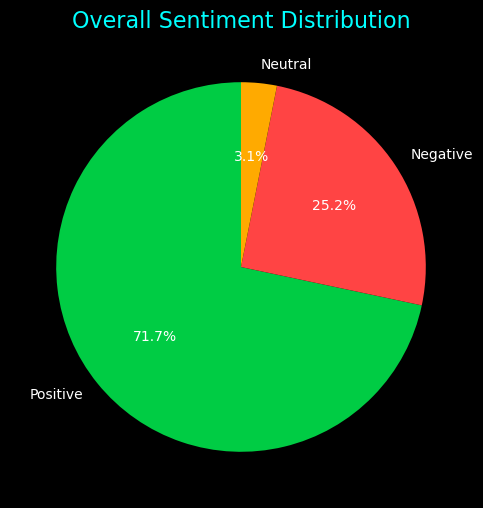

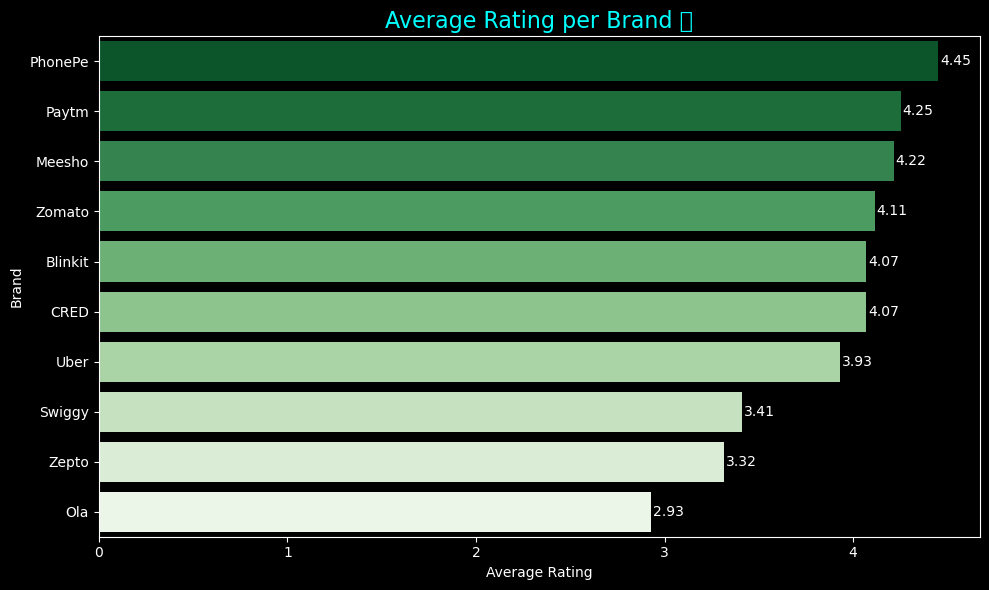

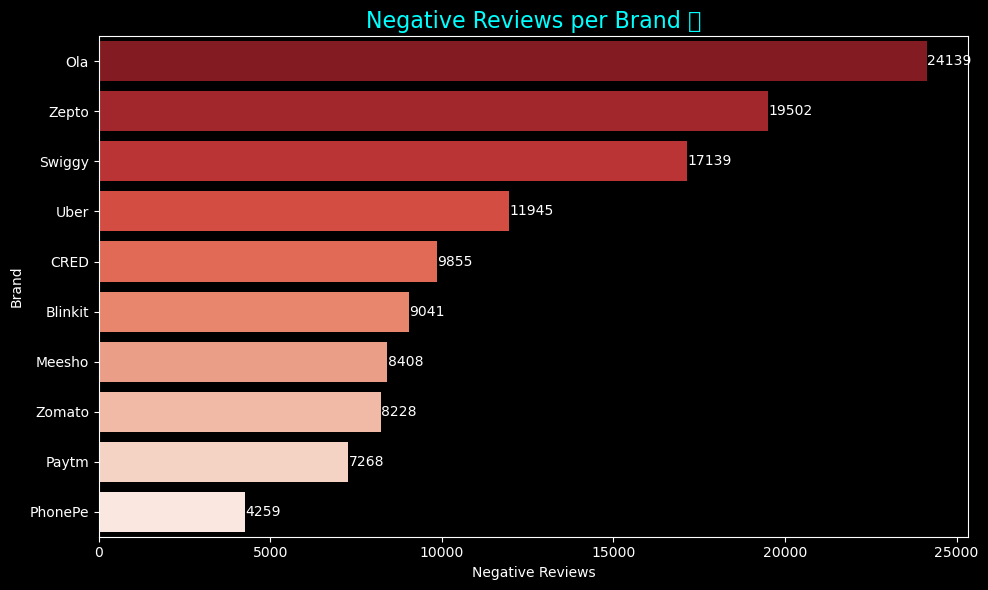

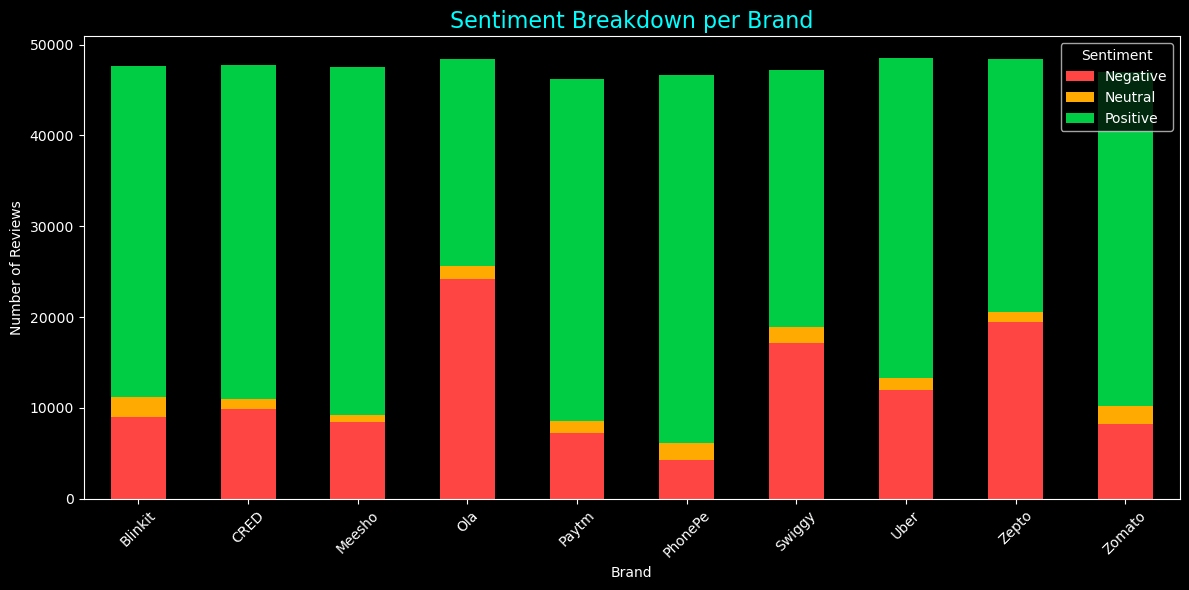

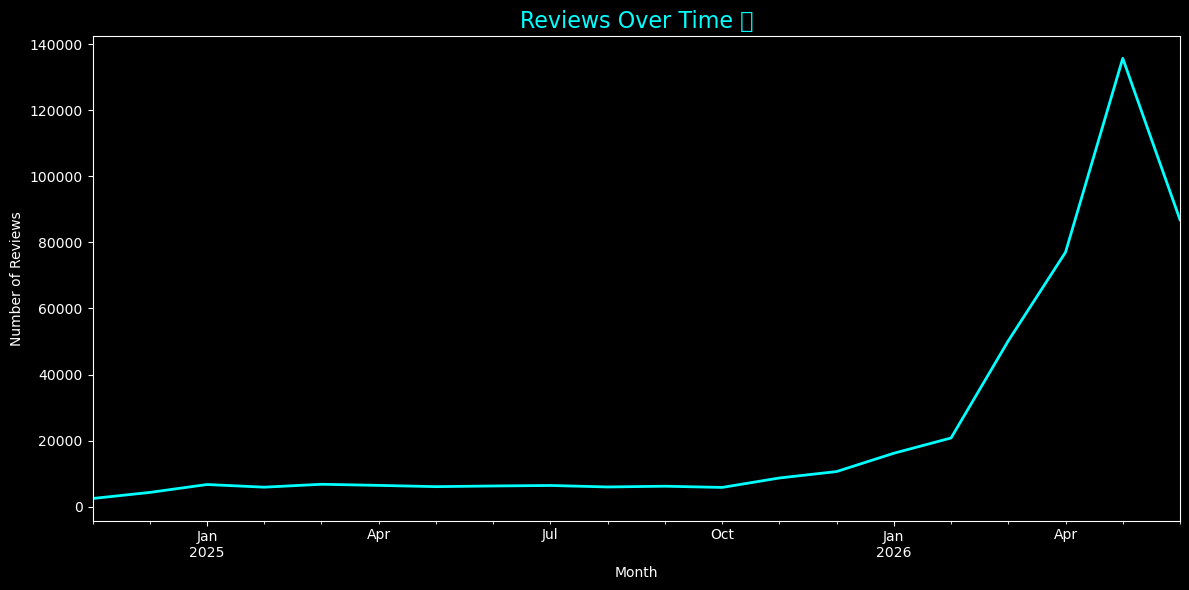

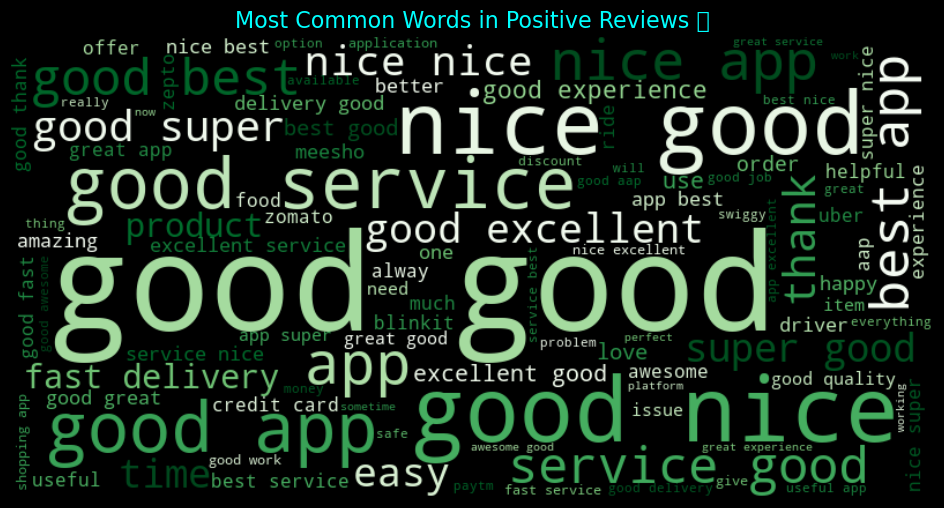

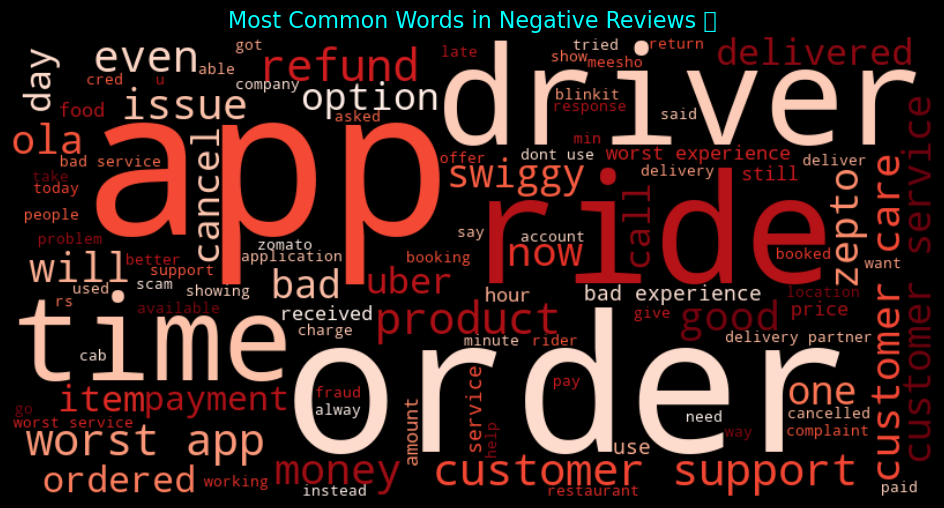

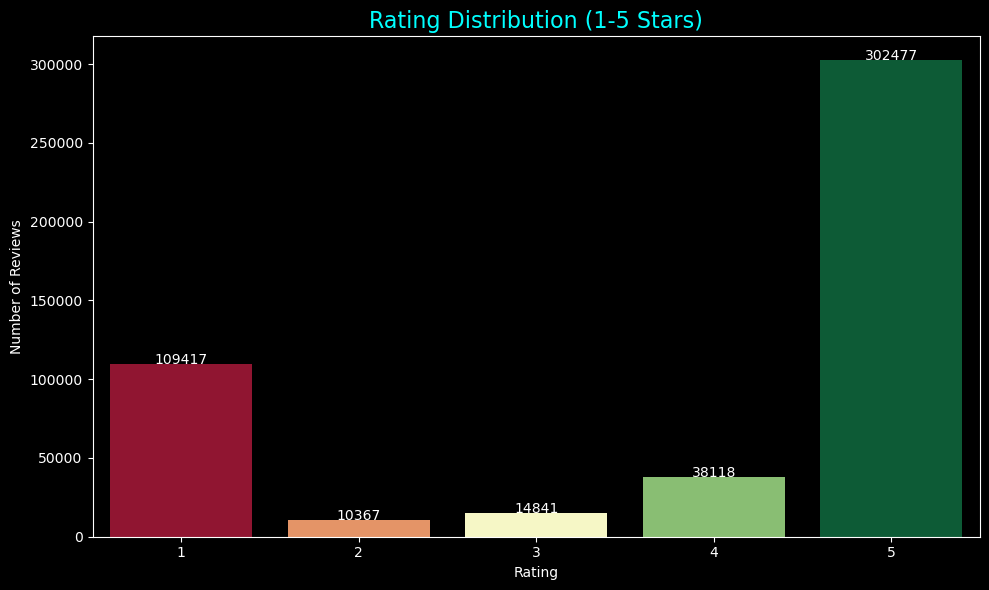

✅ All 8 charts saved!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("cleaned_reviews.csv")

plt.style.use('dark_background')

# ============================================
# Chart 1: Sentiment Distribution Pie Chart
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))
sentiment_counts = df['sentiment'].value_counts()
colors = ['#00cc44', '#ff4444', '#ffaa00']
ax.pie(sentiment_counts.values, labels=sentiment_counts.index,
       colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Sentiment Distribution', color='cyan', fontsize=16)
plt.savefig('chart1_sentiment_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 2: Average Rating per Brand
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))
avg_rating = df.groupby('brand')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.values, y=avg_rating.index,
            hue=avg_rating.index, palette='Greens_r', legend=False, ax=ax)
ax.set_title('Average Rating per Brand ', color='cyan', fontsize=16)
ax.set_xlabel('Average Rating', color='white')
ax.set_ylabel('Brand', color='white')
for i, v in enumerate(avg_rating.values):
    ax.text(v + 0.01, i, f'{v:.2f}', color='white', va='center')
plt.tight_layout()
plt.savefig('chart2_avg_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 3: Negative Reviews per Brand
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))
neg_df = df[df['sentiment'] == 'Negative'].groupby('brand').size().sort_values(ascending=False)
sns.barplot(x=neg_df.values, y=neg_df.index,
            hue=neg_df.index, palette='Reds_r', legend=False, ax=ax)
ax.set_title('Negative Reviews per Brand ', color='cyan', fontsize=16)
ax.set_xlabel('Negative Reviews', color='white')
ax.set_ylabel('Brand', color='white')
for i, v in enumerate(neg_df.values):
    ax.text(v + 10, i, str(v), color='white', va='center')
plt.tight_layout()
plt.savefig('chart3_negative_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 4: Sentiment per Brand Stacked Bar
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))
sentiment_brand = df.groupby(['brand', 'sentiment']).size().unstack(fill_value=0)
sentiment_brand.plot(kind='bar', stacked=True, 
                     color=['#ff4444', '#ffaa00', '#00cc44'],
                     ax=ax)
ax.set_title('Sentiment Breakdown per Brand', color='cyan', fontsize=16)
ax.set_xlabel('Brand', color='white')
ax.set_ylabel('Number of Reviews', color='white')
ax.legend(title='Sentiment', loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart4_sentiment_brand.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 5: Reviews Over Time
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
reviews_over_time = df.groupby('month').size()
reviews_over_time.plot(kind='line', color='cyan', linewidth=2, ax=ax)
ax.set_title('Reviews Over Time ', color='cyan', fontsize=16)
ax.set_xlabel('Month', color='white')
ax.set_ylabel('Number of Reviews', color='white')
plt.tight_layout()
plt.savefig('chart5_reviews_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 6: Word Cloud — Positive Reviews
# ============================================
positive_text = ' '.join(df[df['sentiment'] == 'Positive']['clean_text'].dropna())
wordcloud = WordCloud(width=800, height=400, 
                      background_color='black',
                      colormap='Greens',
                      max_words=100).generate(positive_text)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Positive Reviews ', 
             color='cyan', fontsize=16)
plt.savefig('chart6_positive_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 7: Word Cloud — Negative Reviews
# ============================================
negative_text = ' '.join(df[df['sentiment'] == 'Negative']['clean_text'].dropna())
wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      colormap='Reds',
                      max_words=100).generate(negative_text)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Negative Reviews ',
             color='cyan', fontsize=16)
plt.savefig('chart7_negative_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Chart 8: Rating Distribution
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))
rating_counts = df['rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values,
            hue=rating_counts.index, palette='RdYlGn', legend=False, ax=ax)
ax.set_title('Rating Distribution (1-5 Stars)', color='cyan', fontsize=16)
ax.set_xlabel('Rating', color='white')
ax.set_ylabel('Number of Reviews', color='white')
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 100, str(v), color='white', ha='center')
plt.tight_layout()
plt.savefig('chart8_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(" All 8 charts saved!")